In [129]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler     
from sklearn.decomposition import PCA               
from sklearn.mixture import GaussianMixture
from sklearn.impute import KNNImputer
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score,
                              davies_bouldin_score,
                              calinski_harabasz_score)


In [74]:
df_piura =pd.read_csv('raleo_base_clus_clusteres (1).csv',encoding="ISO-8859-1",sep=',')
df_piura.head()

,data_Persona,data_productividad_per,data_Tcamp,data_sumCOD,data_sumHRSLB,data_GRADO2,data_sum_variedad_total_AL,data_sum_variedad_total_CC,data_sum_variedad_total_CP,data_sum_variedad_total_JS,...,data_total,data_bono_produc,data_otros_bono,dummies_Tsexo_Mujer,sede_cod,data_numero_asistentes,data_asistente_mediana_Tedad,data_asistente_mediana_numero_hijos,data_asistente_dias_empresa,cluster
0,5,268.347619,19,2817.65,10.5,PRIMARIA COMPLETA,12.31,0.00,0.0,0.0,...,51.99,0.49,0.00,0,Ica,2,NaN,NaN,NaN,1
1,11,80.000000,20,560.00,7.0,SECUNDARIA COMPLETA,0.00,0.00,0.0,0.0,...,94.77,4.70,0.00,0,Ica,1,45.0,0.0,2964.0,1
2,14,61.800000,20,618.00,10.0,SECUNDARIA COMPLETA,0.00,0.00,0.0,0.0,...,239.22,0.00,10.25,1,Ica,2,NaN,NaN,NaN,1
3,15,25.333333,20,228.00,9.0,SECUNDARIA COMPLETA,0.00,92.42,0.0,0.0,...,104.43,0.76,12.01,1,Ica,1,32.0,1.0,673.0,1
4,16,55.276000,19,138.19,2.5,SUPERIOR - TECNICO,26.87,0.00,0.0,0.0,...,26.87,0.00,0.00,0,Ica,1,28.0,0.0,NaN,1


Limpieza de Variables

In [75]:
df_piura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22907 entries, 0 to 22906
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   data_Persona                         22907 non-null  int64  
 1   data_productividad_per               22907 non-null  float64
 2   data_Tcamp                           22907 non-null  int64  
 3   data_sumCOD                          22907 non-null  float64
 4   data_sumHRSLB                        22907 non-null  float64
 5   data_GRADO2                          18660 non-null  object 
 6   data_sum_variedad_total_AL           22907 non-null  float64
 7   data_sum_variedad_total_CC           22907 non-null  float64
 8   data_sum_variedad_total_CP           22907 non-null  float64
 9   data_sum_variedad_total_JS           22907 non-null  float64
 10  data_sum_variedad_total_MG           22907 non-null  float64
 11  data_sum_variedad_total_RG  

In [76]:
df_piura.isnull().sum()[df_piura.isnull().sum() > 0]

data_GRADO2                             4247
data_DEUDA_PROM_U6M                    13822
data_PEOR_CALIF_U6M                        2
data_MODA_CALIF_U6M                    10822
data_NRO_ENT_PROM_U6M                  13822
data_TIPCRE_UM                         14453
data_DIAS_ATRASO_PROM_U6M              13822
data_BANCARIZADO                           2
data_distancia                          4998
data_asistente_mediana_Tedad            1830
data_asistente_mediana_numero_hijos     1830
data_asistente_dias_empresa             7341
dtype: int64

In [77]:
(df_piura.isnull().sum()[df_piura.isnull().sum() > 0] / len(df_piura) * 100).sort_values(ascending=False)

data_TIPCRE_UM                         63.094251
data_DEUDA_PROM_U6M                    60.339634
data_NRO_ENT_PROM_U6M                  60.339634
data_DIAS_ATRASO_PROM_U6M              60.339634
data_MODA_CALIF_U6M                    47.243201
data_asistente_dias_empresa            32.046973
data_distancia                         21.818658
data_GRADO2                            18.540184
data_asistente_mediana_numero_hijos     7.988824
data_asistente_mediana_Tedad            7.988824
data_PEOR_CALIF_U6M                     0.008731
data_BANCARIZADO                        0.008731
dtype: float64

In [78]:
vars_a_eliminar = [
    'data_MODA_CALIF_U6M',
    'data_TIPCRE_UM',
    'data_NRO_ENT_PROM_U6M',
    'data_DEUDA_PROM_U6M',
    'data_DIAS_ATRASO_PROM_U6M'
]
df_piura.drop(columns=vars_a_eliminar, inplace=True)

In [79]:
variables_cuantitativas = [
    'data_asistente_dias_empresa', 'data_asistente_mediana_numero_hijos', 
    'data_asistente_mediana_Tedad', 'data_distancia'
]

X_knn = df_piura[variables_cuantitativas].copy()

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')

X_imputed_matriz = knn_imputer.fit_transform(X_knn)
df_piura[variables_cuantitativas] = pd.DataFrame(X_imputed_matriz, columns=variables_cuantitativas, index=df_piura.index)

variables_enteras = [
    'data_Tedad', 'data_numero_hijos', 'data_dias_empresa', 'data_veces',
    'data_asistente_dias_empresa', 'data_asistente_mediana_numero_hijos', 
    'data_asistente_mediana_Tedad'
]

df_piura[variables_enteras] = df_piura[variables_enteras].round().astype(int)

In [80]:
variables_categoricas = ['data_GRADO2', 'data_BANCARIZADO','data_PEOR_CALIF_U6M']

for col in variables_categoricas:
    if col in df_piura.columns:
        moda_col = df_piura[col].mode()[0]
        df_piura[col] = df_piura[col].fillna(moda_col)

Seleccion y edición de variables para el proceso del algoritmo K-Means

In [81]:
VARS_CLUSTER = [
    'data_productividad_per',
    'data_dias_empresa',
    'data_veces',
    'dummies_Tsexo_Mujer',
    'data_Tedad',
    'data_numero_hijos',
    'data_pobreza',
    'data_total'
]

In [82]:
X = df_piura[VARS_CLUSTER]  

In [83]:
vars_gestion = [
   'data_productividad_per',
    'data_dias_empresa',
    'data_veces',
    'data_Tedad',
    'data_numero_hijos',
    'data_pobreza',
    'data_total'
]

In [84]:
for col in vars_gestion:
    skew = X[col].skew()
    print(f"{col:35s}  skewness: {skew:.2f}")

data_productividad_per               skewness: 14.63
data_dias_empresa                    skewness: 6.72
data_veces                           skewness: 1.18
data_Tedad                           skewness: 0.69
data_numero_hijos                    skewness: 1.24
data_pobreza                         skewness: -0.17
data_total                           skewness: 2.08


In [85]:
vars_log = ['data_productividad_per', 'data_dias_empresa', 'data_total']
for col in vars_log:
    X[col + '_log'] = np.log(X[col] + 1)

C:\Users\stefa\AppData\Local\Temp\ipykernel_24432\3272883719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col + '_log'] = np.log(X[col] + 1)
C:\Users\stefa\AppData\Local\Temp\ipykernel_24432\3272883719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col + '_log'] = np.log(X[col] + 1)
C:\Users\stefa\AppData\Local\Temp\ipykernel_24432\3272883719.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

In [86]:
X.columns

Index(['data_productividad_per', 'data_dias_empresa', 'data_veces',
       'dummies_Tsexo_Mujer', 'data_Tedad', 'data_numero_hijos',
       'data_pobreza', 'data_total', 'data_productividad_per_log',
       'data_dias_empresa_log', 'data_total_log'],
      dtype='object')

In [87]:
Xcont=X[['data_veces', 'data_Tedad', 'data_numero_hijos',
       'data_pobreza', 'data_productividad_per_log',
       'data_dias_empresa_log', 'data_total_log']]

In [88]:
X_esc = StandardScaler().fit_transform(Xcont)

In [89]:
X_esc = pd.DataFrame(X_esc, columns=Xcont.columns, index=Xcont.index)

In [90]:
X_esc.columns

Index(['data_veces', 'data_Tedad', 'data_numero_hijos', 'data_pobreza',
       'data_productividad_per_log', 'data_dias_empresa_log',
       'data_total_log'],
      dtype='object')

In [91]:
Xfin = pd.concat([
    X_esc[['data_veces', 'data_Tedad', 'data_numero_hijos', 'data_pobreza',
       'data_productividad_per_log', 'data_dias_empresa_log',
       'data_total_log']],
    X[['dummies_Tsexo_Mujer']]
], axis=1)

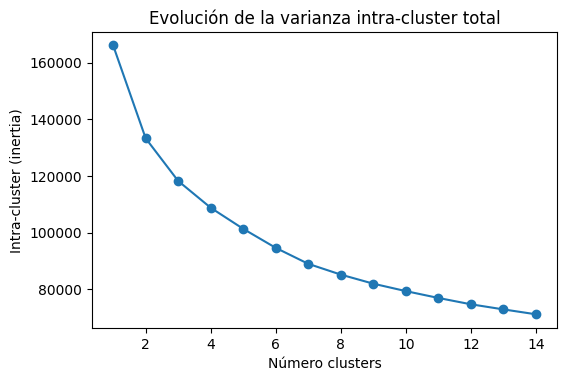

In [92]:
#Hallar el numero de clusters óptimo con el método del codo
range_n_clusters = range(1, 15)
inertias = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters, 
                        n_init       = 20, 
                        random_state = 123
                    )
    modelo_kmeans.fit(Xfin)
    inertias.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

In [132]:
K_OPTIMO = 4
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=123, n_init=20, max_iter=5000)
kmeans.fit(Xfin)

# Asignar clusters al dataframe
df_piura = df_piura.copy()
df_piura['cluster_pred'] = kmeans.labels_
X['cluster_pred'] = kmeans.labels_

# Métricas del modelo
inercia_final    = kmeans.inertia_
sil_final        = silhouette_score(Xfin, kmeans.labels_, sample_size=2000, random_state=123)
inercia_total    = np.sum((Xfin - Xfin.mean(axis=0))**2).sum()
bss_pct = (1 - kmeans.inertia_ / inercia_total) * 100

print(f"   → Inercia final (WCSS):                {inercia_final:,.2f}")
print(f"   → Silhouette Score:                    {sil_final:.4f}")
print(f"   → Suma cuadrados entre clusters (BSS): {bss_pct:.1f}%")


   → Inercia final (WCSS):                108,778.08
   → Silhouette Score:                    0.1482
   → Suma cuadrados entre clusters (BSS): 34.5%


c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [117]:
kmeans.cluster_centers_

array([[-0.58981746, -0.57401079, -0.51813525, -0.11115469, -0.97644549,
        -0.54940717, -1.07393681,  0.44427811],
       [ 1.58716761,  0.45858586,  0.74474781,  0.23810949,  0.48944616,
         0.69163537,  0.59306886,  0.66774962],
       [-0.39112855,  1.11501086,  0.34863967,  0.08869428, -0.21573839,
        -0.00466294, -0.10576781,  0.65747221],
       [-0.253621  , -0.55027774, -0.27185485, -0.11616797,  0.6278537 ,
         0.01784474,  0.57036782,  0.45026954]])

In [118]:
kmeans.labels_

array([1, 2, 1, ..., 3, 2, 0], shape=(22907,), dtype=int32)

In [96]:
a = pd.DataFrame({'kmeans_labels':kmeans.labels_})
a['kmeans_labels'].value_counts()

kmeans_labels
3    7424
0    6007
2    4854
1    4622
Name: count, dtype: int64

Datos y Gráficos de los Clusters

In [103]:
vars_perfil = [
    'data_productividad_per',
    'data_dias_empresa',
    'data_veces',
    'data_n_lote',
    'data_numero_hijos',
    'data_sum_hora_extra',
    'data_distancia',
    'data_total',
    'data_numero_asistentes',
    'data_n_variedad',
    'data_n_fundo',
    'data_sum_aux_bono_total',
    'data_Tedad',
    'dummies_Tsexo_Mujer',
]

perfil = df_piura.groupby('cluster_pred')[vars_perfil].mean().round(2)
print(perfil)

              data_productividad_per  data_dias_empresa  data_veces  \
cluster_pred                                                          
0                              22.72             139.19        1.22   
1                              83.19             582.36        3.85   
2                              47.87             209.90        1.46   
3                             100.34             184.23        1.62   

              data_n_lote  data_numero_hijos  data_sum_hora_extra  \
cluster_pred                                                        
0                    1.66               0.29                 0.47   
1                    8.47               1.36                22.27   
2                    4.68               1.02                 6.64   
3                    8.23               0.50                11.91   

              data_distancia  data_total  data_numero_asistentes  \
cluster_pred                                                       
0                     

In [98]:
v2 = ['data_sum_variedad_total_AL',
    'data_sum_variedad_total_CC',
    'data_sum_variedad_total_JS', 'data_sum_variedad_total_MG',
    'data_sum_variedad_total_RG', 'data_sum_variedad_total_SG', 'data_sum_variedad_total_TM']

In [99]:
perfil2 = df_piura.groupby('cluster_pred')[v2].mean().round(2)
print(perfil2)

              data_sum_variedad_total_AL  data_sum_variedad_total_CC  \
cluster_pred                                                           
0                                  37.75                        8.61   
1                                 154.60                      149.74   
2                                 114.33                       57.21   
3                                 172.44                      105.64   

              data_sum_variedad_total_JS  data_sum_variedad_total_MG  \
cluster_pred                                                           
0                                  48.22                        3.58   
1                                 697.94                      101.36   
2                                 512.28                       35.66   
3                                 742.11                       88.81   

              data_sum_variedad_total_RG  data_sum_variedad_total_SG  \
cluster_pred                                                  

In [104]:
perfil['N_operarios']  = df_piura.groupby('cluster_pred').size()
perfil['%_operarios']  = (perfil['N_operarios'] / len(df_piura) * 100).round(1)
perfil['%_produccion'] = (
    df_piura.groupby('cluster_pred')['data_sumCOD'].sum()
    / df_piura['data_sumCOD'].sum() * 100
).round(1)
perfil['%_importe']    = (
    df_piura.groupby('cluster_pred')['data_total'].sum()
    / df_piura['data_total'].sum() * 100).round(1)

print(perfil[['data_Tedad','N_operarios',
              '%_operarios','%_produccion','dummies_Tsexo_Mujer']])

              data_Tedad  N_operarios  %_operarios  %_produccion  \
cluster_pred                                                       
0                  26.15         6007         26.2           1.5   
1                  36.25         4622         20.2          35.8   
2                  42.70         4854         21.2          11.3   
3                  26.36         7424         32.4          51.4   

              dummies_Tsexo_Mujer  
cluster_pred                       
0                            0.44  
1                            0.67  
2                            0.66  
3                            0.45  


In [ ]:
nombres_clusters = {
    3: "Jóvenes altamente productivos",
    1: "Mujeres adultas productivas",
    2: "Operarios adultos con experiencia",
    0: "Jóvenes de baja productividad"
}
df_piura['segmento'] = df_piura['cluster_pred'].map(nombres_clusters)

print(df_piura['segmento'].value_counts())


segmento
Jóvenes altamente productivos        7424
Jóvenes de baja productividad        6007
Operarios adultos con experiencia    4854
Mujeres adultas productivas          4622
Name: count, dtype: int64


In [105]:
grado = (df_piura
         .groupby('cluster_pred')['data_GRADO2']
         .value_counts(normalize=True)
         .mul(100).round(1)
         .rename('% operarios'))
print(grado.to_string())

cluster_pred  data_GRADO2          
0             SECUNDARIA COMPLETA      61.1
              SECUNDARIA IMCOMPLETA    26.2
              PRIMARIA COMPLETA         5.8
              PRIMARIA INCOMPLETA       5.6
              ILETRADO                  0.8
              SUPERIOR - TECNICO        0.4
1             SECUNDARIA COMPLETA      44.1
              SECUNDARIA IMCOMPLETA    27.6
              PRIMARIA COMPLETA        14.9
              PRIMARIA INCOMPLETA       9.1
              ILETRADO                  2.6
              SUPERIOR - TECNICO        1.8
2             SECUNDARIA COMPLETA      42.4
              PRIMARIA COMPLETA        21.8
              SECUNDARIA IMCOMPLETA    17.9
              PRIMARIA INCOMPLETA       9.4
              ILETRADO                  4.9
              SUPERIOR - TECNICO        3.6
              EDUCACION ESPECIAL        0.0
3             SECUNDARIA COMPLETA      54.9
              SECUNDARIA IMCOMPLETA    27.8
              PRIMARIA COMPLETA         

In [ ]:
estado = (df_piura
          .groupby('cluster_pred')['data_Testado_civil']
          .value_counts(normalize=True)
          .mul(100).round(1)
          .rename('% operarios'))
print(estado.to_string())


cluster_pred  data_Testado_civil              
0             Soltero(a)                          96.6
              Casado(a)/conviviente/unionlibre     3.3
              Viudo(a)                             0.0
              Divorciado(a)/separado(a)            0.0
1             Soltero(a)                          86.7
              Casado(a)/conviviente/unionlibre    13.2
              Viudo(a)                             0.1
              Divorciado(a)/separado(a)            0.0
2             Soltero(a)                          85.9
              Casado(a)/conviviente/unionlibre    13.6
              Viudo(a)                             0.3
              Divorciado(a)/separado(a)            0.2
3             Soltero(a)                          95.3
              Casado(a)/conviviente/unionlibre     4.5
              Divorciado(a)/separado(a)            0.1
              Viudo(a)                             0.1


In [ ]:
banc = (df_piura
        .groupby('cluster_pred')['data_BANCARIZADO']
        .value_counts(normalize=True)
        .mul(100).round(1)
        .rename('% operarios'))
print(banc.to_string())

cluster_pred  data_BANCARIZADO
0             1.0                 61.3
              0.0                 38.7
1             1.0                 86.7
              0.0                 13.3
2             1.0                 87.9
              0.0                 12.1
3             1.0                 67.1
              0.0                 32.9


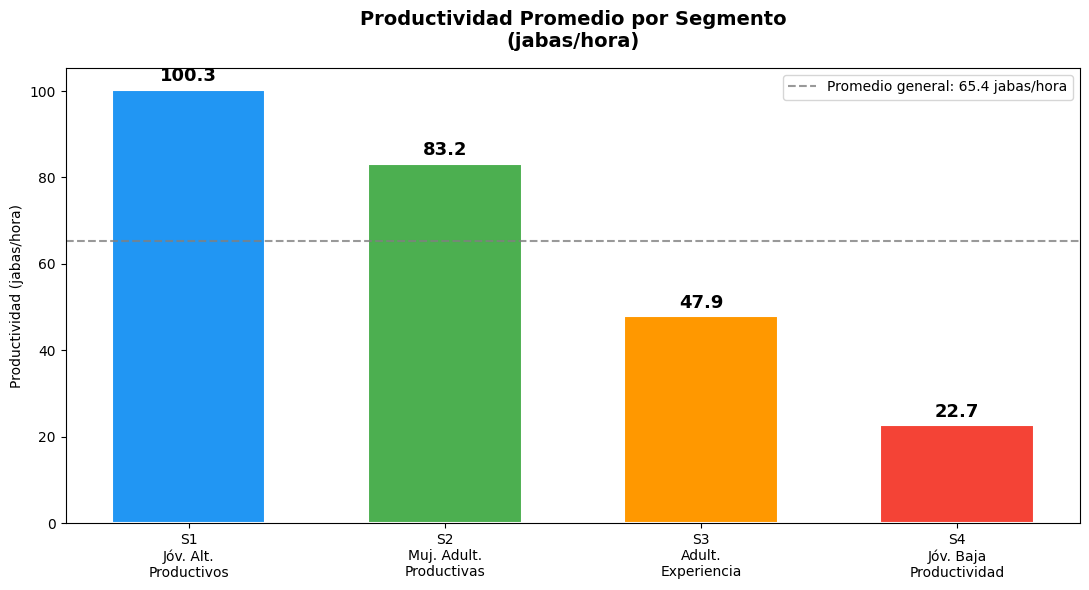

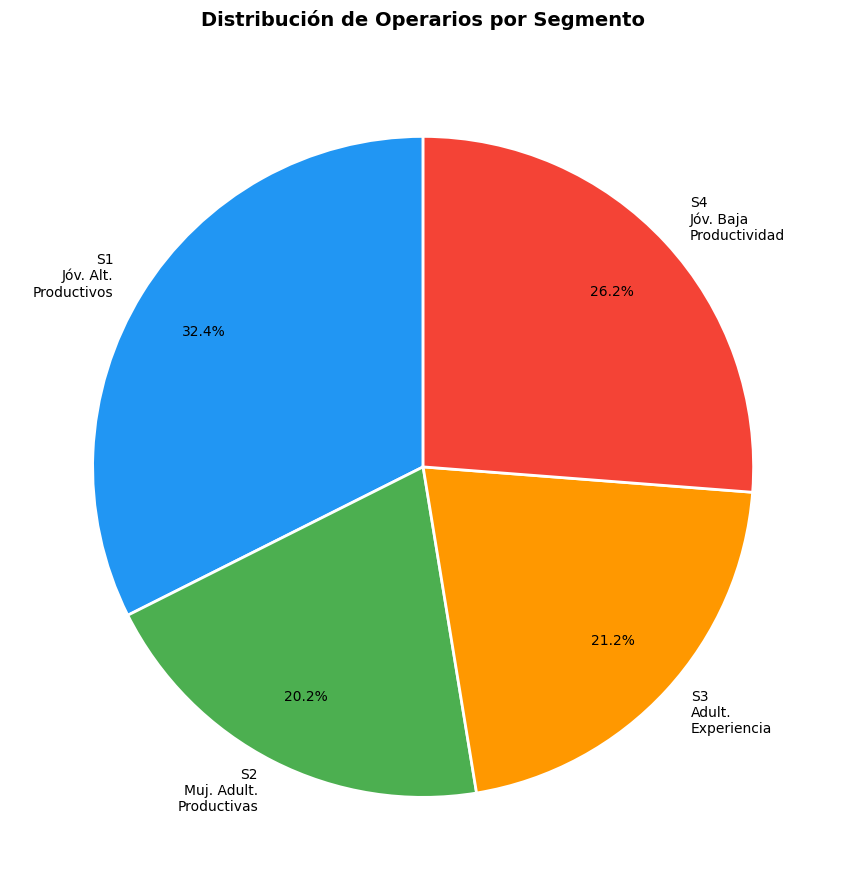

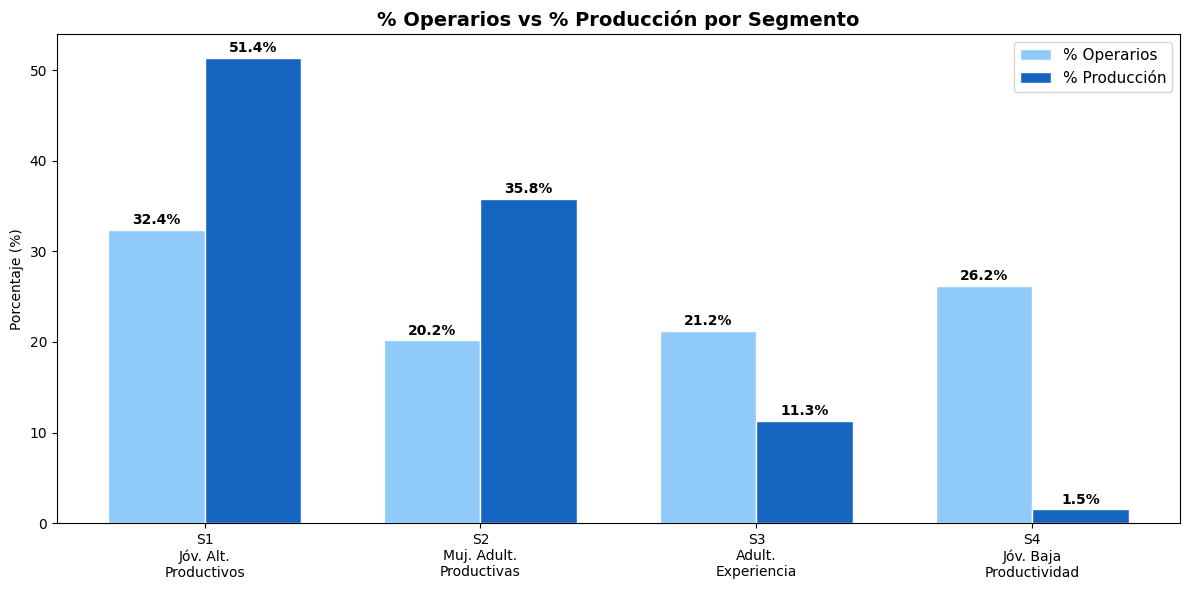

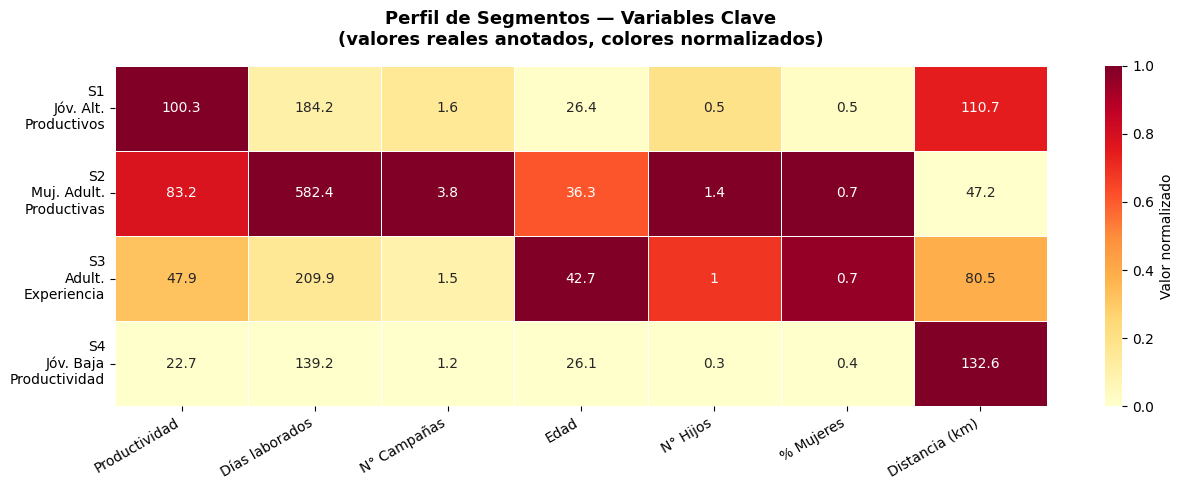

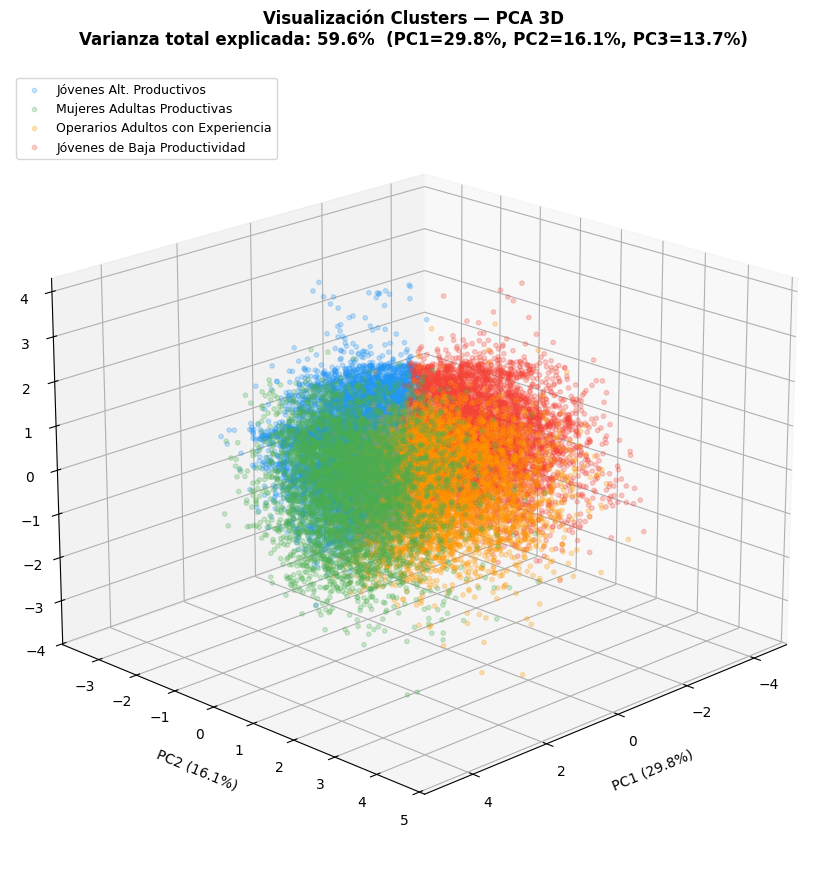

In [131]:
orden       = [3, 1, 2, 0]
nombres     = {3:'Jóvenes Alt. Productivos', 1:'Mujeres Adultas Productivas',
               2:'Operarios Adultos con Experiencia',  0:'Jóvenes de Baja Productividad'}
etiq_cortas = ['S1\nJóv. Alt.\nProductivos','S2\nMuj. Adult.\nProductivas',
               'S3\nAdult.\nExperiencia',   'S4\nJóv. Baja\nProductividad']
COLS        = ['#2196F3','#4CAF50','#FF9800','#F44336']

prod_seg = [df_piura[df_piura['cluster_pred']==c]
            ['data_productividad_per'].mean() for c in orden]
fig, ax = plt.subplots(figsize=(11,6))
bars = ax.bar(etiq_cortas, prod_seg, color=COLS,
              edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, prod_seg):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}', ha='center', va='bottom',
            fontweight='bold', fontsize=13)
prom = df_piura['data_productividad_per'].mean()
ax.axhline(prom, color='gray', linestyle='--', alpha=0.8,
           label=f'Promedio general: {prom:.1f} jabas/hora')
ax.set_title('Productividad Promedio por Segmento\n(jabas/hora)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Productividad (jabas/hora)')
ax.legend()
plt.tight_layout()
plt.savefig('g1_productividad.png', dpi=150, bbox_inches='tight')
plt.show()

conteo = [df_piura[df_piura['cluster_pred']==c].shape[0] for c in orden]
fig, ax = plt.subplots(figsize=(9,9))
ax.pie(conteo, labels=etiq_cortas, colors=COLS,
       autopct='%1.1f%%', startangle=90, pctdistance=0.78,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Distribución de Operarios por Segmento',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('g2_torta_operarios.png', dpi=150, bbox_inches='tight')
plt.show()

pct_op   = [df_piura[df_piura['cluster_pred']==c].shape[0]
             /len(df_piura)*100 for c in orden]
pct_prod = [df_piura[df_piura['cluster_pred']==c]['data_sumCOD'].sum()
             /df_piura['data_sumCOD'].sum()*100 for c in orden]
x = np.arange(len(orden)); w = 0.35
fig, ax = plt.subplots(figsize=(12,6))
b1 = ax.bar(x-w/2, pct_op,   w, label='% Operarios',
            color='#90CAF9', edgecolor='white')
b2 = ax.bar(x+w/2, pct_prod, w, label='% Producción',
            color='#1565C0', edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(etiq_cortas, fontsize=10)
ax.set_title('% Operarios vs % Producción por Segmento',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('g3_operarios_vs_produccion.png', dpi=150, bbox_inches='tight')
plt.show()

vars_heat = ['data_productividad_per','data_dias_empresa',
             'data_veces','data_Tedad','data_numero_hijos',
             'dummies_Tsexo_Mujer','data_distancia']
labs_heat = ['Productividad','Días laborados','N° Campañas',
             'Edad','N° Hijos','% Mujeres','Distancia (km)']
heat_data = (df_piura.groupby('cluster_pred')[vars_heat]
             .mean().reindex(orden))
heat_data.index = etiq_cortas
heat_norm = ((heat_data - heat_data.min())
             / (heat_data.max() - heat_data.min()))
fig, ax = plt.subplots(figsize=(13,5))
sns.heatmap(heat_norm, annot=heat_data.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            xticklabels=labs_heat,
            cbar_kws={'label':'Valor normalizado'})
ax.set_title('Perfil de Segmentos — Variables Clave\n'
             '(valores reales anotados, colores normalizados)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(labs_heat, rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('g4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#Se realiza PCA para visualizar los clusters en 3D
pca     = PCA(n_components=3, random_state=123)
X_pca   = pca.fit_transform(Xfin)
var_exp = pca.explained_variance_ratio_

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for i, c in enumerate(orden):
    mask = df_piura['cluster_pred'].values == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], X_pca[mask,2],
               c=COLS[i], alpha=0.25, s=10, label=nombres[c])


ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})', labelpad=10)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})', labelpad=10)
ax.set_zlabel(f'PC3 ({var_exp[2]:.1%})', labelpad=10)
ax.set_title(
    f'Visualización Clusters — PCA 3D\n'
    f'Varianza total explicada: {sum(var_exp):.1%}  '
    f'(PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}, '
    f'PC3={var_exp[2]:.1%})',
    fontsize=12, fontweight='bold', pad=20)
ax.legend(fontsize=9, loc='upper left')
ax.view_init(elev=20, azim=45)  # ángulo de vista

plt.tight_layout()
plt.savefig('g6_pca3d.png', dpi=150, bbox_inches='tight')
plt.show()


Descripción de los Clusters Obtenidos

Cluster 3 — Jóvenes Altamente Productivos (32.4%)

El grupo más productivo y numeroso de la campaña.

Productividad y producción:

- Productividad de 100.34 jabas/hora — la más alta de todos los segmentos
- Con el 32.4% de operarios genera el 51.4% de toda la producción
- Trabajaron en promedio 2.51 variedades de uva y 2.72 fundos distintos — lo que indica versatilidad y movilidad dentro del campo
- Acumularon 11.91 horas extra en promedio y un bono de S/ 535.62

Perfil demográfico:

- Jóvenes de 26 años en promedio
- Composición mixta: 55% hombres y 45% mujeres
- Principalmente solteros (95.3%), con 0.50 hijos en promedio
- Educación: secundaria completa (54.9%) y secundaria incompleta (27.8%)

Comportamiento laboral:

- Trabajaron 184 días en promedio durante la campaña
- Han participado en 1.62 campañas — son relativamente nuevos pero ya productivos
- Trabajaron en promedio 8.23 lotes distintos — los que más lotes cubren después del C1
- 4.24 asistentes promedio con quienes trabajaron

Situación geográfica y financiera:

- Viven a 110.68 km del fundo — distancia media
- Ingreso total promedio de S/ 1,314.72 — segundo ingreso más alto
- 67.1% está bancarizado


Respecto a las variedades de jabas, sus tres variedades principales son Jack's Salute, Timpson y Red Globe. Son las variedades de mayor volumen y que requieren más habilidad, lo que es coherente con su alta productividad.


Conclusión: Son jóvenes con alta capacidad productiva y buena adaptabilidad. A pesar de tener poca antigüedad, su productividad supera ampliamente al promedio. Son el grupo más valioso en términos de producción.

-------------------------------------------------------------------------------------------------------------------------------------

Cluster 1 — Mujeres Adultas Productivas (20.2%)

El grupo más experimentado y constante de la campaña.

Productividad y producción:

- Productividad de 83.19 jabas/hora — segunda más alta
- Con solo el 20.2% de operarios genera el 35.8% de la producción
- Mayor bono promedio de todos: S/ 576.16 — refleja su constancia y desempeño
- 22.27 horas extra acumuladas — las más altas de todos los clusters

Perfil demográfico:

- Adultos de 36 años en promedio
- Predominantemente mujeres: 67% mujeres, 33% hombres
- Solteros en su mayoría (86.7%), con 1.36 hijos en promedio — los que más carga familiar tienen
- Educación: secundaria completa (44.1%), secundaria incompleta (27.6%) y primaria completa (14.9%)
- Mayor presencia de iletrados (2.6%) respecto a C3

Comportamiento laboral:

- Los más constantes: 582 días trabajados en promedio — casi el doble que C3
- Han participado en 3.85 campañas — los más experimentados de todos
- Trabajaron en 8.47 lotes y 2.86 fundos — los que más lotes cubren
- 4.94 asistentes promedio — los que más asistentes tienen

Situación geográfica y financiera:

- Viven más cerca al fundo: 47.21 km — la menor distancia de todos los clusters
- Ingreso total promedio de S/ 1,495.53 — el más alto de todos
- 86.7% está bancarizado — el nivel más alto

Respecto a las variedades de jabas, sus variedades principales son Jack's Salute, Timpson y Red Globe. Tienen la mayor presencia en Cotton Candy (149.74) y Magenta (101.36) respecto al resto, lo que refleja su versatilidad y experiencia con variedades más exigentes.

Conclusión: Son el grupo más leal y rentable a largo plazo. Su experiencia acumulada (casi 4 campañas), su cercanía al fundo y su altísima constancia (582 días) los hacen indispensables. La empresa debería priorizar su retención.

-------------------------------------------------------------------------------------------------------------------------------------

Cluster 2 — Operarios Adultos con Experiencia Media (21.2%)

El grupo de mayor edad con productividad intermedia.

Productividad y producción:

- Productividad de 47.87 jabas/hora — tercera posición
- Con el 21.2% de operarios genera el 11.3% de la producción
- Bono promedio de S/ 128.32 y 6.64 horas extra
- Trabajaron en 1.86 variedades y 1.96 fundos — menor diversidad que C1 y C3

Perfil demográfico:

- Los más mayores: 42.7 años en promedio
- Predominantemente mujeres: 66% mujeres, 34% hombres
- Solteros (85.9%), con 1.02 hijos en promedio
- Educación: secundaria completa (42.4%), primaria completa (21.8%) — mayor nivel de primaria que el resto
- Mayor presencia de iletrados (4.9%) y educación especial (0.0%)

Comportamiento laboral:

- Trabajaron 209 días en promedio
- Han participado en 1.46 campañas — poca antigüedad pese a su edad avanzada
- Trabajaron en 4.68 lotes y 1.96 fundos
- 2.93 asistentes promedio

Situación geográfica y financiera:

- Viven a 80.48 km del fundo — distancia intermedia
- Ingreso total promedio de S/ 587.86
- 87.9% está bancarizado — el más alto de todos los clusters

Respecto a las variedades de jabas, sus variedades principales son Jack's Salute, Timpson y Allison. Los volúmenes son menores que C1 y C3 en todas las variedades, coherente con su productividad media y menor constancia laboral.

Conclusión: Son operarios mayores que llegaron relativamente tarde a la empresa (1.46 campañas). Su productividad es moderada posiblemente por la combinación de edad avanzada y poca experiencia en raleo. Su alta bancarización sugiere mayor formalidad económica.

-------------------------------------------------------------------------------------------------------------------------------------

Cluster 0 — Jóvenes de Baja Productividad (26.2%)

El grupo más problemático: muchos operarios, poca producción.

Productividad y producción:

- Productividad de 22.72 jabas/hora — la más baja
- Con el 26.2% de operarios genera apenas el 1.5% de la producción
- Bono casi nulo: S/ 4.10 y solo 0.47 horas extra
- Trabajaron en apenas 1.18 variedades y 1.19 fundos — la menor diversidad de todos

Perfil demográfico:

- Jóvenes de 26 años en promedio — misma edad que C3
- Composición mixta: 56% hombres y 44% mujeres
- Casi todos solteros (96.6%), con solo 0.29 hijos — los menos comprometidos familiarmente
- Educación: secundaria completa (61.1%) y secundaria incompleta (26.2%)

Comportamiento laboral:

- Los menos constantes: apenas 139 días trabajados — menos de la mitad que C3
- Han participado en 1.22 campañas — los más nuevos junto con C2
- Solo 1.19 fundos trabajados — prácticamente estuvieron en un solo lugar
- 1.51 asistentes promedio — los que menos interacción laboral tienen

Situación geográfica y financiera:

- Viven más lejos: 132.60 km del fundo — la mayor distancia de todos
- Ingreso total promedio de apenas S/ 115.06 — el más bajo
- Solo 61.3% bancarizado — el nivel más bajo

Respecto a las variedades de jabas, sus variedades principales son Jack's Salute, Allison y Sugraone, pero con volúmenes notablemente bajos en todas. Prácticamente no tuvieron presencia en Magenta (3.58) ni Cotton Candy (8.61), que son variedades que requieren más experiencia y técnica.

Conclusión: Son jóvenes nuevos que no lograron integrarse bien a la campaña. La combinación de lejanía al fundo (132 km), poca experiencia (1.22 campañas), pocos días trabajados (139) y alta rotación explica su bajísima productividad. Representan un alto costo de selección y capacitación para la empresa con muy poco retorno productivo.

Comparación de métricas con otro Modelo, en este caso el GMM

In [ ]:
labels_km = kmeans.labels_
gmm = GaussianMixture(n_components=4,
                      random_state=123,
                      n_init=20)

labels_gmm = gmm.fit_predict(Xfin)

resultados = {}

for nombre, labels in [('K-Means', labels_km),
                        ('GMM',     labels_gmm)]:

    sil = silhouette_score(Xfin, labels,
                           sample_size=2000,
                           random_state=123)
    db  = davies_bouldin_score(Xfin, labels)
    ch  = calinski_harabasz_score(Xfin, labels)

    resultados[nombre] = {
        'Silhouette':        round(sil, 4),
        'Davies-Bouldin':    round(db,  4),
        'Calinski-Harabasz': round(ch,  1),
    }

    print(f"\n  {nombre}:")
    print(f"  Silhouette Score     : {sil:.4f}")
    print(f"  Davies-Bouldin Score : {db:.4f}")
    print(f"  Calinski-Harabasz    : {ch:.1f}")


print("\n Resumen")
df_comp = pd.DataFrame(resultados).T

print(df_comp.to_string())

#Sobre estos indicadores es importante mencionar que:
# - El Silhouette Score es una métrica que evalúa la cohesión y separación de los clusters. Un valor cercano a 1 indica clusters bien definidos, mientras que un valor cercano a -1 sugiere clusters superpuestos o mal definidos.
# - El Davies-Bouldin Score mide la relación entre la dispersión intra-cluster y la separación entre clusters. Un valor más bajo indica clusters más compactos y mejor separados.
# - El Calinski-Harabasz Score evalúa la relación entre la dispersión entre clusters y la dispersión intra-cluster. Un valor más alto indica clusters más definidos y separados.



  K-Means:
  Silhouette Score     : 0.1482
  Davies-Bouldin Score : 1.8740
  Calinski-Harabasz    : 4019.2

  GMM:
  Silhouette Score     : 0.0383
  Davies-Bouldin Score : 4.2177
  Calinski-Harabasz    : 1920.1

 Resumen
         Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means      0.1482          1.8740             4019.2
GMM          0.0383          4.2177             1920.1


Las tres métricas coinciden en que K-Means logra una estructura de clusters más clara y mejor definida que GMM en estos datos. Esto sugiere que los grupos presentes probablemente tienen una forma relativamente compacta y cercana al supuesto esférico que utiliza K-Means.